In [ ]:
# Install required libraries
!pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
np.random.seed(42)

n = 500

data = pd.DataFrame({
    'age': np.random.randint(22, 60, n),
    'experience': np.random.randint(1, 20, n),
    'department': np.random.choice(['HR','IT','Sales'], n),
    'salary': np.random.randint(20000, 100000, n),
    'training_hours': np.random.randint(5, 100, n),
    'attendance': np.random.uniform(0.6, 1.0, n)
})

# Create performance logic
data['performance'] = np.where(
    (data['training_hours'] > 60) & (data['attendance'] > 0.85),
    'High',
    np.where(
        (data['training_hours'] > 30),
        'Medium',
        'Low'
    )
)

data.head()

,age,experience,department,salary,training_hours,attendance,performance
0,50,2,Sales,81246,72,0.913959,High
1,36,5,Sales,21435,17,0.883072,Low
2,29,5,IT,46660,53,0.915446,Medium
3,42,6,IT,25084,64,0.806908,Medium
4,40,19,IT,33507,6,0.776080,Low


In [ ]:
print("Dataset Info:\n")
print(data.info())

print("\nStatistical Summary:\n")
print(data.describe())

print("\nMissing Values:\n")
print(data.isnull().sum())

Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             500 non-null    int64  
 1   experience      500 non-null    int64  
 2   department      500 non-null    object 
 3   salary          500 non-null    int64  
 4   training_hours  500 non-null    int64  
 5   attendance      500 non-null    float64
 6   performance     500 non-null    object 
dtypes: float64(1), int64(4), object(2)
memory usage: 27.5+ KB
None

Statistical Summary:

              age  experience        salary  training_hours  attendance
count  500.000000  500.000000    500.000000      500.000000  500.000000
mean    41.322000    9.822000  59839.134000       48.566000    0.797857
std     11.051633    5.615816  22858.017206       28.264029    0.114496
min     22.000000    1.000000  20281.000000        5.000000    0.600626
25%     32.000000    5.00

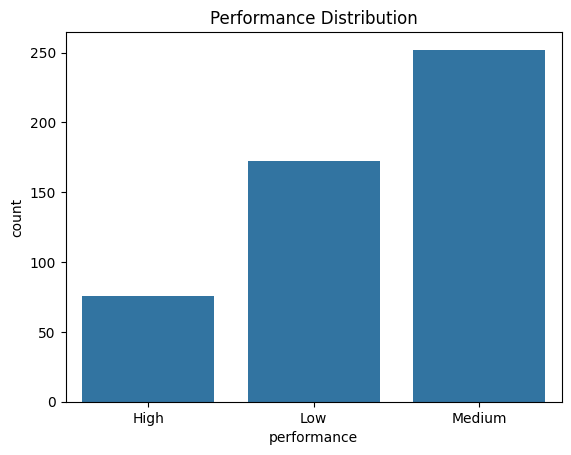

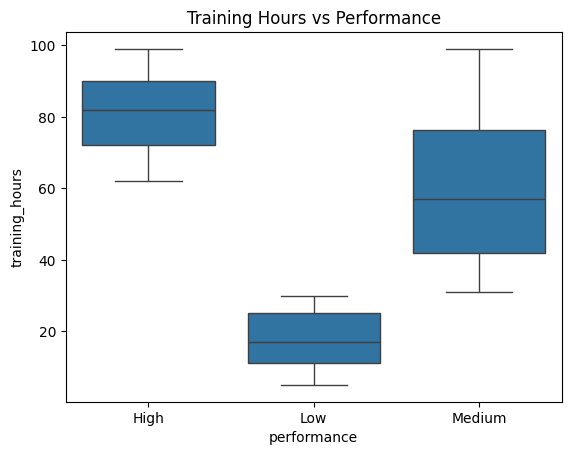

In [ ]:
# Performance distribution
sns.countplot(x='performance', data=data)
plt.title("Performance Distribution")
plt.show()

# Training hours vs performance
sns.boxplot(x='performance', y='training_hours', data=data)
plt.title("Training Hours vs Performance")
plt.show()

In [ ]:
le = LabelEncoder()

data['department'] = le.fit_transform(data['department'])
data['performance'] = le.fit_transform(data['performance'])

data.head()

,age,experience,department,salary,training_hours,attendance,performance
0,50,2,2,81246,72,0.913959,0
1,36,5,2,21435,17,0.883072,1
2,29,5,1,46660,53,0.915446,2
3,42,6,1,25084,64,0.806908,2
4,40,19,1,33507,6,0.776080,1


In [ ]:
X = data.drop('performance', axis=1)
y = data['performance']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (400, 6)
Testing Data: (100, 6)


In [ ]:
model = RandomForestClassifier()

model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


In [ ]:
y_pred = model.predict(X_test)

print("Predictions:\n", y_pred[:10])

Predictions:
 [2 2 1 0 2 2 1 1 2 1]


In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:

[[18  0  0]
 [ 0 31  0]
 [ 0  0 51]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        18
           1       1.00      1.00      1.00        31
           2       1.00      1.00      1.00        51

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



          Feature  Importance
4  training_hours    0.718316
5      attendance    0.179002
3          salary    0.042940
0             age    0.028378
1      experience    0.022926
2      department    0.008438


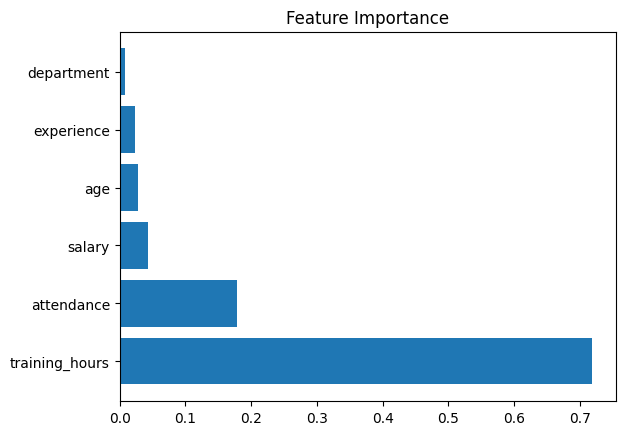

In [ ]:
importances = model.feature_importances_
features = X.columns

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df)

# Plot
plt.figure()
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.title("Feature Importance")
plt.show()

In [ ]:
new_employee = pd.DataFrame({
    'age': [30],
    'experience': [5],
    'department': [1],  # encoded value
    'salary': [50000],
    'training_hours': [70],
    'attendance': [0.9]
})

prediction = model.predict(new_employee)

print("Predicted Performance:", prediction)

Predicted Performance: [0]


In [ ]:
import joblib

# Save model
joblib.dump(model, 'employee_model.pkl')

# Save dataset
data.to_csv('employee_data.csv', index=False)

print("Model & Data Saved")

Model & Data Saved


In [ ]:
from google.colab import files

files.download('employee_model.pkl')
files.download('employee_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>